# Search performance

One figure combining the planner model benchmark (A–C), the published mimicry pairs
under visual similarity (D), and the vector index benchmark (E). Each part draws exactly what its own
notebook draws (`model_performance`, `mimicry`, `index_performance`), through the same
helpers; see those notebooks and `analyses/README.md` for definitions.

Needs a plannerbench run (`reports/latest.json`), a completed index benchmark under
`results/indexing/`, and the backend stopped so DuckDB and LanceDB are readable.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "backend/app/configs/config.yaml").is_file()
)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
from analyses.helpers import mimicry, planner
from analyses.helpers.indexing import index_benchmark, index_panel
from analyses.helpers.publication import export_figure, load_settings, publication_style

settings = load_settings(ROOT)
publication_style()

N_PERMUTATIONS = 10_000
SEED = 0

## Load the three sources

In [3]:
run = planner.load_planner_run(ROOT)
print(planner.describe(run))
unavailable = planner.unavailable_models(run)

if unavailable:
    print(
        "WARNING: no successful calls for: "
        + ", ".join(unavailable)
        + ". Treat these as access/provider failures, not model-performance results."
    )

results = mimicry.mimicry_results(settings, ROOT, N_PERMUTATIONS, SEED)
print(mimicry.describe(results))

benchmark = index_benchmark(ROOT)
print(f"Benchmark source: {benchmark.attrs['source_run']}")

Run: 9b24daaa-2369-40a5-9a34-44f7b1c700fe
Production model: gemma-4-31b-it
Prompt fingerprint: cdbf17ec5ecb80c9e9e439e1ce0f9bd38673315ca426d574701f1e9772372e6b
18 cases × 5 repeats × 5 models = 450 recorded trials
11 pairs tested, covering 18 species; ranked among 8,360 species and 468,775 dorsal images; Lance version 4172
Not tested: H. numata – M. ludovica (M) (Heliconius numata: no dorsal images in the collection)
Not tested: H. numata – M. marsaeus (M) (Heliconius numata: no dorsal images in the collection)
Not tested: H. numata – M. menophilus (M) (Heliconius numata: no dorsal images in the collection)
Benchmark source: /home/hhandika/Codes/websites/BioCosmos/analyses/results/indexing/20260926T165312Z_fdd49ff1


## Combined figure

A–B) Planner accuracy against p50 latency and tokens per successful call; outlined models
are Pareto leaders. C) Share of correct repeats per model and case. D) Mimicry partner rank
by nearest dorsal image, dorsal against dorsal, beside the two images that matched and each
species' dorsal image count (N); shaded, bold pairs are mutual top ten. E) Index mean latency against recall@10; outlined indexes
are each embedding's Pareto leaders. The permutation and pair tests are in the `mimicry` figure.

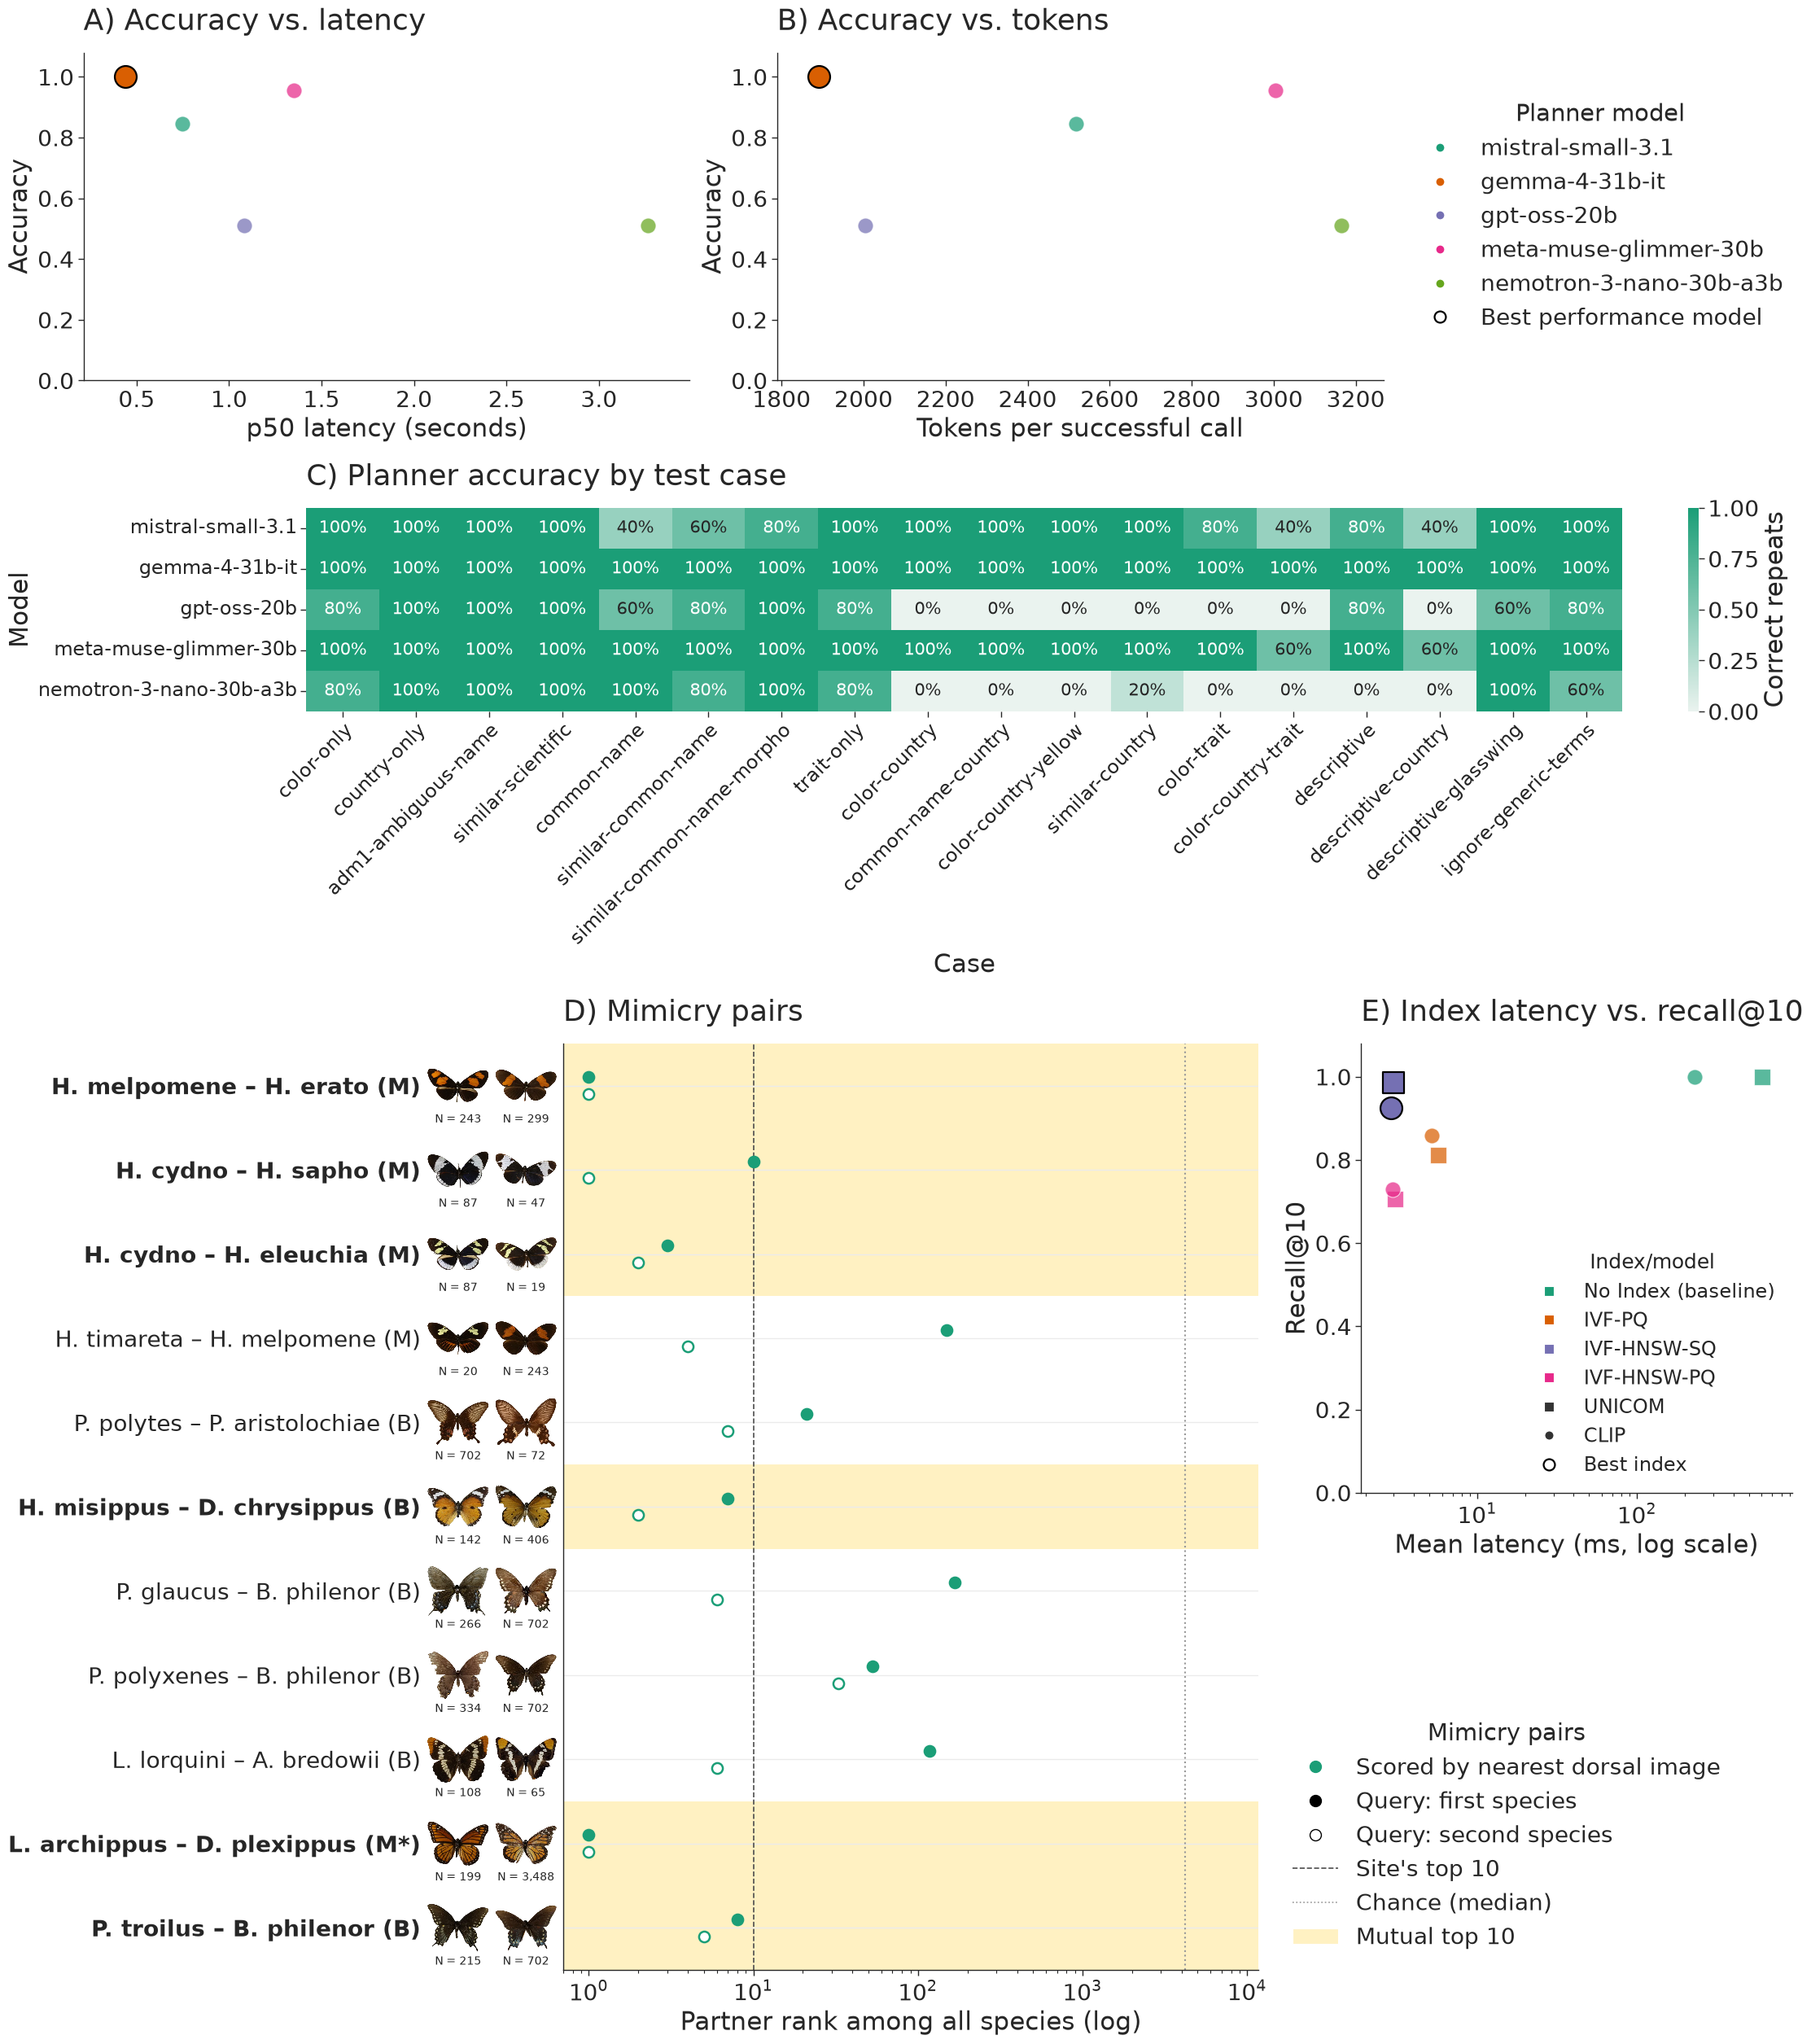

In [4]:
# Larger text than the standalone figures: this one is printed at the same page width
# with more panels, so each must stay legible when reduced.
COMBINED_STYLE = {
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 21,
    "axes.titlepad": 20,
}
heatmap_height = max(6, len(run.models) * 1.3)

with plt.rc_context(COMBINED_STYLE):
    fig = plt.figure(figsize=(22, 5.5 + heatmap_height + 13), layout="constrained")
    top, middle, bottom = fig.subfigures(3, 1, height_ratios=(5.5, heatmap_height, 13))

    # A–B: planner quality against cost, with the model legend beside them.
    top_axes = top.subplots(1, 3, gridspec_kw={"width_ratios": (1, 1, 0.62)})

    for ax, (cost_column, xlabel, title) in zip(
        top_axes[:2],
        (
            ("latency_p50_seconds", "p50 latency (seconds)", "A) Accuracy vs. latency"),
            ("tokens_per_success", "Tokens per successful call", "B) Accuracy vs. tokens"),
        ),
        strict=True,
    ):
        planner.quality_cost_panel(
            ax, run, cost_column, xlabel, title, title_loc="left", marker_scale=2.5
        )
        # Room for the enlarged markers at full accuracy and at either end of the axis.
        ax.set_ylim(0, 1.08)
        ax.margins(x=0.08)

    top_axes[2].axis("off")
    top_axes[2].legend(
        handles=planner.model_legend_handles(run),
        title="Planner model",
        loc="center left",
        frameon=False,
    )

    # C: planner accuracy per case.
    planner.per_case_panel(
        middle.subplots(),
        run,
        "C) Planner accuracy by test case",
        "left",
        label_size=17,
        value_size=15,
    )

    # D: mimicry pairs; E: index benchmark beside it, with D's legend in the space below.
    grid = bottom.add_gridspec(2, 2, width_ratios=(1, 0.62), height_ratios=(1.15, 1))
    ax_pairs = bottom.add_subplot(grid[:, 0])
    ax_index = bottom.add_subplot(grid[0, 1])
    legend_ax = bottom.add_subplot(grid[1, 1])
    handles = mimicry.pairs_panel(
        ax_pairs, results, results.pictures(ROOT), "D) Mimicry pairs", legend=False
    )
    legend_ax.axis("off")
    # Beside D's lower right corner, in the empty space under E; kept out of the layout
    # so it does not shrink the panels.
    pairs_legend = legend_ax.legend(
        handles=handles,
        title="Mimicry pairs",
        loc="lower left",
        bbox_to_anchor=(1.02, 0),
        bbox_transform=ax_pairs.transAxes,
        frameon=False,
    )
    pairs_legend.set_in_layout(False)
    index_panel(ax_index, benchmark, legend_fontsize=17, marker_scale=2.5)
    ax_index.set_ylim(0, 1.08)
    ax_index.margins(x=0.08)
    ax_index.set_title("E) Index latency vs. recall@10", loc="left")

    export_figure(
        fig,
        settings,
        "search_performance",
        {
            "planner_quality_cost": planner.trade_off_data(run),
            "planner_per_case": planner.per_case_data(run),
            **{
                f"mimicry_{name}": frame
                for name, frame in results.exports().items()
                if name in mimicry.PANEL_EXPORTS
            },
            "index_measurements": benchmark,
        },
    )
    plt.show()
plt.close(fig)